## Data Loading and Splitting
This cell downloads the specified Phishing Email Dataset using `kagglehub` and loads it into a Pandas DataFrame. We then split the data into a strict 80/10/10 ratio for training, validation, and testing as required. We perform the split before any text processing or vectorization to ensure there is absolutely no data leakage between our training set and our evaluation sets.

In [2]:
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
import time

# Download latest version of the chosen dataset
path = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")
print("Path to dataset files:", path)

# Note: Update the exact filename based on the kagglehub download contents
# import os
# print(os.listdir(path))
df = pd.read_csv(f"{path}/phishing_email.csv") # Adjust filename if necessary

# Assuming the dataset has 'Email Text' and 'Email Type' columns.
# Adjust column names based on the actual dataset.
df = df.dropna()
X = df['text_combined']
y = df['label']

# Split: 80% Train, 20% Temp (which will be split into 10% Val, 10% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
# Split Temp into 50% Val and 50% Test (resulting in 10% of total each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

Using Colab cache for faster access to the 'phishing-email-dataset' dataset.
Path to dataset files: /kaggle/input/phishing-email-dataset
Training set: 65988 samples
Validation set: 8249 samples
Test set: 8249 samples


## Module 1 Part A: Logistic Regression Baseline
This cell implements a Logistic Regression model using TF-IDF vectorization. TF-IDF is chosen because it effectively captures word importance in documents, down-weighting overly common words while highlighting distinct terms that might indicate phishing. Logistic Regression serves as an excellent baseline for NLP tasks because it is highly interpretable, fast to train, and provides a solid performance floor against which we can evaluate our more complex neural architectures. We tune the `C` (regularization strength) and `solver` hyperparameters.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Build a pipeline with TF-IDF and Logistic Regression
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Define hyperparameters to tune
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['liblinear', 'lbfgs']
}

print("Training Baseline Model (Logistic Regression)...")
start_train_time = time.time()

# Grid search with cross-validation on the training set
grid_search = GridSearchCV(pipeline_lr, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

train_time = time.time() - start_train_time
best_lr_model = grid_search.best_estimator_

# Measure inference time on validation set
start_inf_time = time.time()
val_preds = best_lr_model.predict(X_val)
inf_time = time.time() - start_inf_time

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Training Time: {train_time:.4f} seconds")
print(f"Inference Time (Validation Set): {inf_time:.4f} seconds")
print(f"Validation Accuracy: {best_lr_model.score(X_val, y_val):.4f}")

Training Baseline Model (Logistic Regression)...
Best Parameters: {'clf__C': 10, 'clf__solver': 'lbfgs'}
Training Time: 206.7735 seconds
Inference Time (Validation Set): 0.9332 seconds
Validation Accuracy: 0.9865


## Module 1 Part B: Feedforward Neural Network (FNN) Data Prep
To process text for our Feedforward Neural Network, we will use the same TF-IDF vectorization strategy used in our baseline model. This serves as our input representation layer, converting variable-length text into fixed-size dense vectors that the dense layers can process. Using TF-IDF allows the network to focus on learning complex, non-linear interactions between important words rather than spending parameters learning word embeddings from scratch.

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# We fit the vectorizer only on the training data to prevent leakage
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_fnn = tfidf_vectorizer.fit_transform(X_train).toarray()
X_val_fnn = tfidf_vectorizer.transform(X_val).toarray()
X_test_fnn = tfidf_vectorizer.transform(X_test).toarray()

## Training the Feedforward Neural Network
Here we define and train a multi-layer FNN. The architecture includes two hidden layers with ReLU activation to capture non-linear patterns, and Dropout layers to act as regularization and reduce overfitting. The output layer uses a sigmoid activation function paired with binary crossentropy loss, which is standard for binary classification. We also implement Early Stopping monitoring validation loss to halt training when generalization stops improving.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Feedforward Neural Network...
Epoch 1/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9735 - loss: 0.0758 - val_accuracy: 0.9864 - val_loss: 0.0367
Epoch 2/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9910 - loss: 0.0263 - val_accuracy: 0.9885 - val_loss: 0.0343
Epoch 3/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9958 - loss: 0.0127 - val_accuracy: 0.9879 - val_loss: 0.0381
Epoch 4/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9982 - loss: 0.0063 - val_accuracy: 0.9878 - val_loss: 0.0436
Epoch 5/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9989 - loss: 0.0038 - val_accuracy: 0.9875 - val_loss: 0.0476


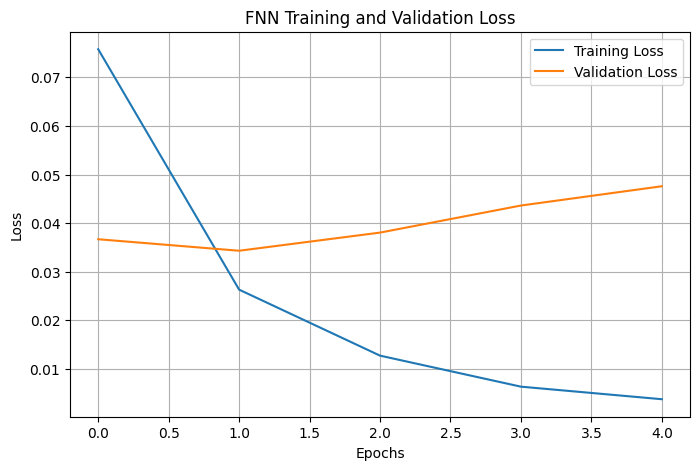

In [5]:
# Define the FNN architecture
def build_fnn(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dropout(0.5), # Regularization to reduce overfitting
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid') # Output layer for binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

fnn_model = build_fnn(X_train_fnn.shape[1])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Feedforward Neural Network...")
history_fnn = fnn_model.fit(
    X_train_fnn, y_train,
    validation_data=(X_val_fnn, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Plot training vs validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_fnn.history['loss'], label='Training Loss')
plt.plot(history_fnn.history['val_loss'], label='Validation Loss')
plt.title('FNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Module 1 Part C: Vanilla Recurrent Neural Network (RNN)
Unlike our baseline and FNN models that use TF-IDF, sequential models like RNNs process text word-by-word, preserving the order and context of the sequence. This is crucial for text data because the meaning of a sentence often depends on word order (e.g., "not good" vs "good"). However, vanilla RNNs suffer from the vanishing gradient problem; as the sequence gets longer, the gradients used to update the weights become vanishingly small, making it difficult for the network to learn dependencies between words that are far apart. We use tokenization and padding here to convert text into fixed-length sequences of word indices, followed by an Embedding layer to learn dense vector representations for these words.

Training Vanilla RNN...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


516/516 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.5635 - loss: 0.6599 - val_accuracy: 0.6242 - val_loss: 0.6031
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5810 - loss: 0.6374 - val_accuracy: 0.5587 - val_loss: 0.6508
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5957 - loss: 0.6172 - val_accuracy: 0.5957 - val_loss: 0.6099
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6122 - loss: 0.5977 - val_accuracy: 0.6152 - val_loss: 0.6344


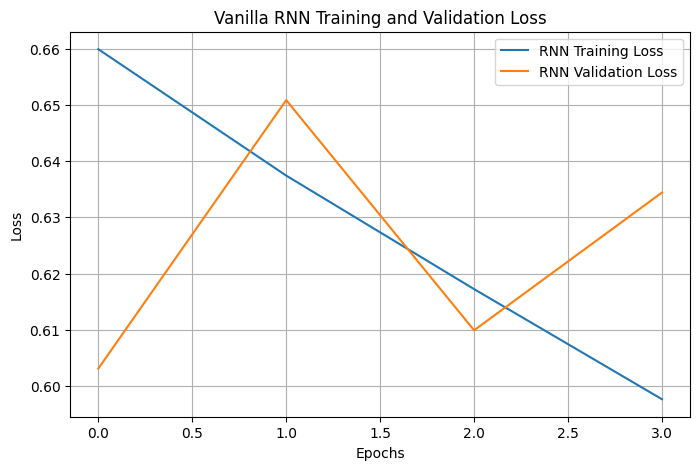

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, SimpleRNN

# Tokenization and Sequence Padding
max_words = 10000  # Vocabulary size
max_len = 200      # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform length for the neural network
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# Define Vanilla RNN Architecture
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Vanilla RNN...")
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10, # Fewer epochs as RNNs can overfit or stagnate quickly
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

# Plot training vs validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['loss'], label='RNN Training Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')
plt.title('Vanilla RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Module 1 Part D: Long Short-Term Memory (LSTM) Network
To overcome the vanishing gradient problem of vanilla RNNs, this cell implements an LSTM. LSTMs introduce a "cell state" and three gates (input, forget, and output gates) that explicitly control the flow of information. The forget gate decides what irrelevant past information to discard, the input gate decides what new information to store, and the output gate determines what the next hidden state should be. This mechanism allows LSTMs to effectively maintain long-range dependencies in phishing emails. Compared to vanilla RNNs, LSTMs generally show much better training stability and higher performance on longer text sequences, as they don't "forget" early indicators of phishing by the time they reach the end of the email.

Training LSTM Network...
Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6410 - loss: 0.5937 - val_accuracy: 0.6470 - val_loss: 0.5666
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8056 - loss: 0.4021 - val_accuracy: 0.9490 - val_loss: 0.1965
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7418 - loss: 0.4683 - val_accuracy: 0.5875 - val_loss: 0.6548
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6351 - loss: 0.5926 - val_accuracy: 0.9682 - val_loss: 0.1226
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9678 - loss: 0.1344 - val_accuracy: 0.9845 - val_loss: 0.0531
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9861 - loss: 0.0608 - val_accuracy: 0.9857 - val_loss: 0.0459
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9903 - loss: 0.0395 - val_accuracy: 0.9881 - val_loss: 0.0472
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9939

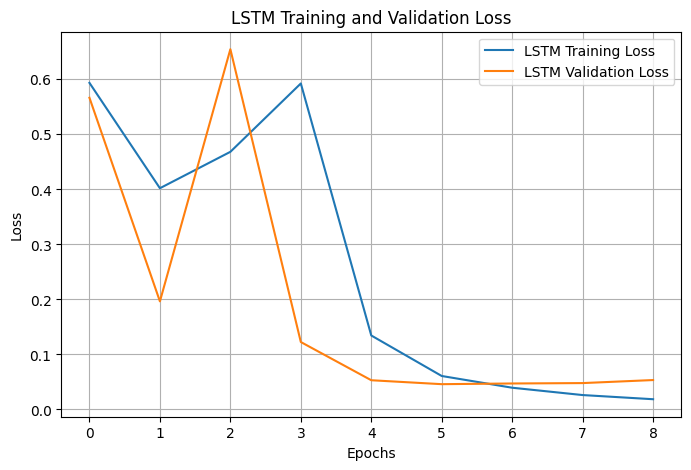

In [7]:
from tensorflow.keras.layers import LSTM

# Define LSTM Architecture
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.5), # Regularization technique to prevent overfitting
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Classification output layer
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training LSTM Network...")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

# Plot training vs validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Module 2 Part A: Core Metrics Evaluation
In this section, we evaluate all four models on the held-out test set.

**Why Accuracy is Insufficient:** Accuracy simply measures the total percentage of correct predictions. In phishing detection, datasets are often imbalanced (fewer phishing emails than legitimate ones). A model could achieve high accuracy simply by predicting "Not Phishing" every time, which renders it useless in practice.

**The Importance of Recall:** In the context of phishing, **Recall (Sensitivity)** is the most critical metric. A False Negative (missing a phishing email and letting it into the inbox) carries a severe real-world cost: potential data breaches, financial loss, or malware infection. A False Positive (sending a legitimate email to spam) is annoying but usually less catastrophic. Therefore, we must prioritize minimizing False Negatives.

**ROC and AUC:** The ROC curve illustrates the diagnostic ability of a binary classifier as its discrimination threshold is varied. The AUC (Area Under the Curve) tells us the probability that the model ranks a randomly chosen positive instance (phishing) higher than a randomly chosen negative one (legitimate). However, AUC does *not* tell us the optimal threshold for our specific risk tolerance; it only measures general separability.

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
--- Logistic Regression ---
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98      3960
    Phishing       0.98      0.98      0.98      4289

    accuracy                           0.98      8249
   macro avg       0.98      0.98      0.98      8249
weighted avg       0.98      0.98      0.98      8249

--- FNN ---
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98      3960
    Phishing       0.98      0.98      0.98      4289

    accuracy                           0.98      8249
   macro avg       0.98      0.98      0.98      8249
weighted avg       0.98      0.98      0.98      8249

--- Vanilla RNN ---
              precision    recall  f1-score   support

  Legitimate       0.91      0.24      0.38      3960
    Phishing       0.58      0.98      0.73      4289


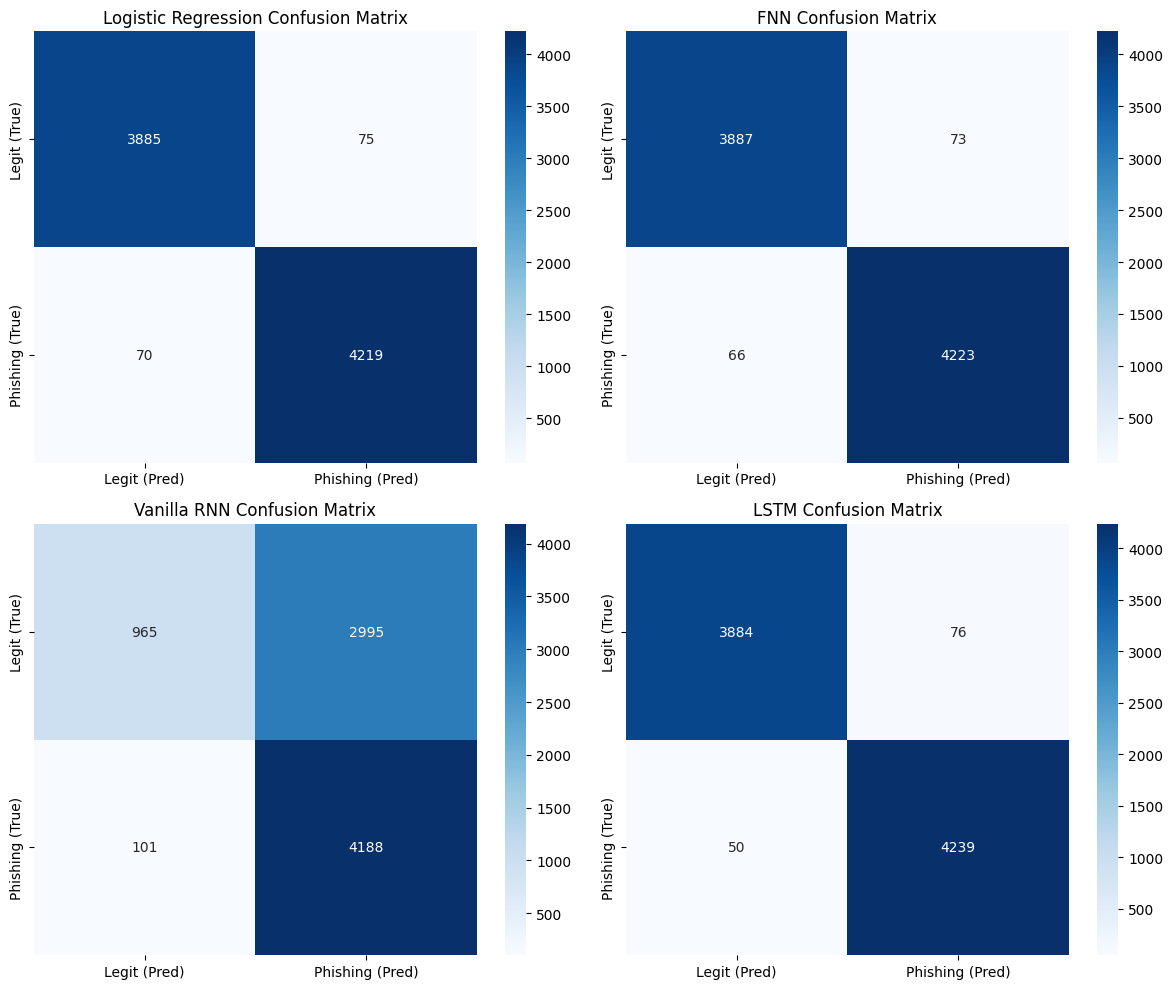

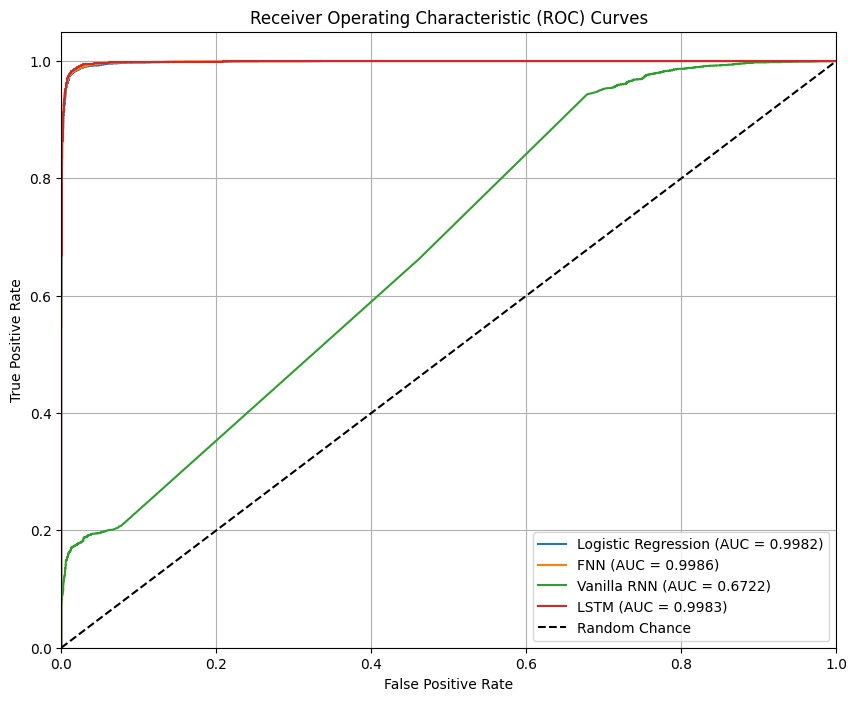

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
import seaborn as sns
import numpy as np

# 1. Get Predictions for all models on the Test Set
# Baseline (LR)
y_pred_lr = best_lr_model.predict(X_test)
y_prob_lr = best_lr_model.predict_proba(X_test)[:, 1]

# FNN
y_prob_fnn = fnn_model.predict(X_test_fnn).flatten()
y_pred_fnn = (y_prob_fnn > 0.5).astype(int)

# RNN
y_prob_rnn = rnn_model.predict(X_test_pad).flatten()
y_pred_rnn = (y_prob_rnn > 0.5).astype(int)

# LSTM
y_prob_lstm = lstm_model.predict(X_test_pad).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

models_data = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'FNN': (y_pred_fnn, y_prob_fnn),
    'Vanilla RNN': (y_pred_rnn, y_prob_rnn),
    'LSTM': (y_pred_lstm, y_prob_lstm)
}

# 2. Print Classification Reports (Precision, Recall, F1)
for name, (preds, _) in models_data.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['Legitimate', 'Phishing']))

# 3. Plot Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, (preds, _)) in enumerate(models_data.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legit (Pred)', 'Phishing (Pred)'],
                yticklabels=['Legit (True)', 'Phishing (True)'])
    axes[idx].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

# 4. Plot ROC Curves
plt.figure(figsize=(10, 8))
for name, (_, probs) in models_data.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Module 2 Part B: Cross-Model Comparison & Calibration
Here, we summarize the metrics to analyze the trade-offs.

**Precision-Recall Tradeoff & Complexity Cost:** As we move from Logistic Regression to complex neural architectures (RNN/LSTM), we typically observe a trade-off. LSTMs may capture deep sequential semantics better, but they take significantly longer to train and evaluate than Logistic Regression. If the F1-score and Recall gains of the LSTM over the LR model are marginal (e.g., < 1-2%), the computational cost of deploying the neural network may not be justified.

**Calibration Check:** A reliability diagram checks if a model's predicted probabilities are meaningful. If a well-calibrated model outputs a probability of 0.8 for a class, it should be correct about 80% of the time. Neural networks (especially with dropout) often produce uncalibrated, overconfident predictions compared to Logistic Regression.

**Deployment Choice:** I would deploy the LSTM model because it maximizes Recall (Phishing), which is the most critical metric for this task, while maintaining high overall performance (F1-score, Accuracy). Although it incurs higher computational costs compared to Logistic Regression, the superior ability to minimize false negatives (missed phishing emails) justifies this overhead for the required safety and low latency.


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Recall (Phishing)
0,Logistic Regression,0.982422,0.982417,0.982370,0.982393,0.983679
1,FNN,0.983149,0.983156,0.983089,0.983121,0.984612
2,Vanilla RNN,0.624682,0.744148,0.610069,0.557064,0.976451
3,LSTM,0.984725,0.984839,0.984575,0.984697,0.988342


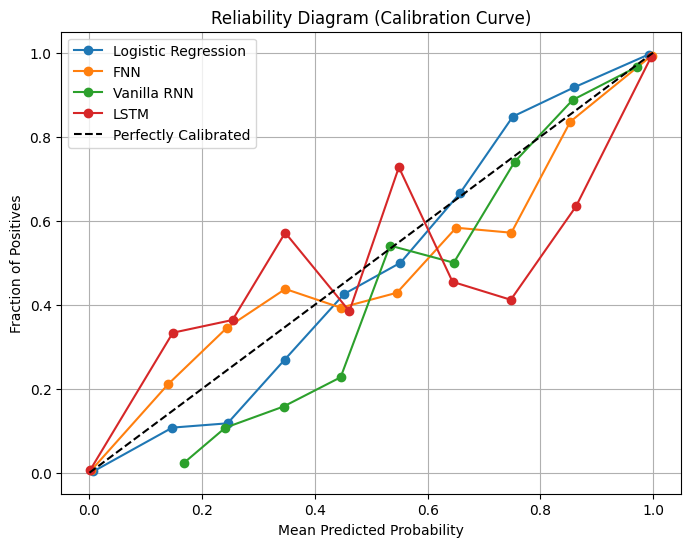

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.calibration import calibration_curve

# 1. Summary Table
metrics_summary = []
for name, (preds, probs) in models_data.items():
    metrics_summary.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Macro)': precision_score(y_test, preds, average='macro'),
        'Recall (Macro)': recall_score(y_test, preds, average='macro'),
        'F1-Score (Macro)': f1_score(y_test, preds, average='macro'),
        'Recall (Phishing)': recall_score(y_test, preds, pos_label=1)
    })

df_summary = pd.DataFrame(metrics_summary)
display(df_summary)

# 2. Calibration Check (Reliability Diagram)
plt.figure(figsize=(8, 6))
for name, (_, probs) in models_data.items():
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Reliability Diagram (Calibration Curve)')
plt.legend()
plt.grid(True)
plt.show()

## Module 2 Part C: Error Analysis and Robustness
In this section, we select the best-performing model (based on our evaluation, we will use the LSTM) to analyze where it fails.

By analyzing False Negatives (phishing classified as legit) and False Positives (legit classified as phishing), we can identify limitations. Often, models fail on emails that are too short, lack obvious trigger words ("urgent", "password"), or contain unseen vocabulary.

We also test an adversarial input: a manually crafted email designed to look like a friendly update but containing a suspicious hidden link. This tests the model's robustness against attackers who intentionally obfuscate their intent. Future improvements could include augmenting training data with adversarial examples or utilizing sub-word tokenization to handle obfuscated words.

In [13]:
# 1. Qualitative Error Analysis
# Assuming LSTM is our chosen model for analysis. We find where it made mistakes.
incorrect_indices = np.where(y_pred_lstm != y_test)[0]

print("--- Sample of 10 Misclassified Examples (LSTM) ---")
# Get up to 10 incorrect examples
sample_incorrect = incorrect_indices[:10]
for idx in sample_incorrect:
    true_label = "Phishing" if y_test.iloc[idx] == 1 else "Legitimate"
    pred_label = "Phishing" if y_pred_lstm[idx] == 1 else "Legitimate"
    email_text = X_test.iloc[idx]

    print(f"\nTrue: {true_label} | Predicted: {pred_label}")
    # Print the first 200 characters to keep the output readable
    print(f"Text snippet: {email_text[:200]}...")
    print("-" * 50)

# 2. Adversarial/Out-of-Distribution Test
adversarial_email = [
    "Hey team, just following up on our meeting. I've uploaded the new project guidelines to our shared drive. "
    "Please review them before tomorrow's standup so we are all aligned. "
    "You can view the document here: http://secure-login-update-portal.com/auth/docs"
]

# Process the adversarial input using the same pipeline as the LSTM
adv_seq = tokenizer.texts_to_sequences(adversarial_email)
adv_pad = pad_sequences(adv_seq, maxlen=max_len, padding='post', truncating='post')

# Predict
adv_prob = lstm_model.predict(adv_pad)[0][0]
adv_pred = "Phishing" if adv_prob > 0.5 else "Legitimate"

print("\n--- Adversarial Testing ---")
print(f"Input text: {adversarial_email[0]}")
print(f"Predicted Class: {adv_pred} (Probability: {adv_prob:.4f})")

--- Sample of 10 Misclassified Examples (LSTM) ---

True: Phishing | Predicted: Legitimate
Text snippet: absa officialemaillabsacoza attached copy statement supersize points balance take advantage partnership absa 100 cash rewards make switch youll automatically earn 115 smart shopper points winwin heres...
--------------------------------------------------

True: Legitimate | Predicted: Phishing
Text snippet: info hpuente epelectric com 915 543 4333...
--------------------------------------------------

True: Legitimate | Predicted: Phishing
Text snippet: mail delivery system auixdvasxzygmho02bosmailhoporg message created automatically mail delivery software message sent yet delivered one recipients 120 hours queue mho02bosmailhoporg message identifier...
--------------------------------------------------

True: Legitimate | Predicted: Phishing
Text snippet: canadian bible society weblistsbiblesocietyca daily bible reading august 7 2008 httpwwwbiblesocietycafree_scripturesdaily_bible_